Task 1: Data Loading and Exploration
1.	Load the Titanic Dataset
2.	Inspect the dataset:
○	Display column names, data types, and summary statistics using Pandas.
○	Identify missing values and discuss their implications.


In [69]:
# importing all imp libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# loading data set and displaying first 5 rows
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [73]:
# describing the statistical calcculations of the data
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [74]:
# displaying the columns and data type and much more
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [75]:
# checking which columns have null values and how many
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Discussion: Missing Values & Their Implications
🔹 Age

Problem: Missing ages reduce model accuracy.

Impact: Age is important for survival prediction.

Possible solution: Fill with mean/median or predict using other features.

🔹 Cabin

Problem: Too many missing values.

Impact: Hard to use directly.

Possible solution: Drop column or create a new feature like Has_Cabin.

🔹 Embarked

Problem: Very few missing values.

Impact: Small effect.

Possible solution: Fill with most frequent value (mode).

In [ ]:
Task 2: Data Cleaning and Manipulation
1.	Handle missing values:
○	Fill missing values in the Age column with the median age.
○	Drop rows with zero values in the Fare column.
2.	Create new features:
○	Add a family_size feature by combining sibsp (siblings/spouses) and parch (parents/children).
○	Create a travel_alone feature indicating whether the passenger traveled alone.
3.	Filter data:
○	Select passengers aged between 18 and 50 and save the subset as a new DataFrame.


In [76]:
# task 2
# filling the missing valus of age column with its median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [77]:
# again checking missing valus and now the Age column has 0 missing valus
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [78]:
# froping rows where fare is 0
df.drop(df[df['Fare']==0].index , inplace = True)

In [79]:
# creating a new column family_size and fill it with total family size
df['family_size'] = df['SibSp'] + df['Parch'] + 1

In [80]:
# displaying columns names
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 876 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  876 non-null    int64  
 1   Survived     876 non-null    int64  
 2   Pclass       876 non-null    int64  
 3   Name         876 non-null    object 
 4   Sex          876 non-null    object 
 5   Age          876 non-null    float64
 6   SibSp        876 non-null    int64  
 7   Parch        876 non-null    int64  
 8   Ticket       876 non-null    object 
 9   Fare         876 non-null    float64
 10  Cabin        201 non-null    object 
 11  Embarked     874 non-null    object 
 12  family_size  876 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 95.8+ KB


In [81]:
# displaying first 5 rows of data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [82]:
# adding new column travel_alone
df['travel_alone'] = df['family_size'] == 1

In [83]:
# displaying first 5 rows of data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,travel_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,True


In [84]:
# selecting rows where age is between 18 and 50
age_subset = df[(df['Age'] >= 18) & (df['Age'] <= 50)]


In [45]:
age_subset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,travel_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,True


Task 3: Exploratory Data Analysis
1.	Analyze categorical variables:
○	Visualize the survival rate by gender and passenger
2.	Analyze numerical variables:
○	Plot a histogram for the Age column and overlay the median.
○	Create a box plot of Fare across different passenger classes.
3.	Detect correlations:
○	Compute and visualize the correlation matrix using heatmap.


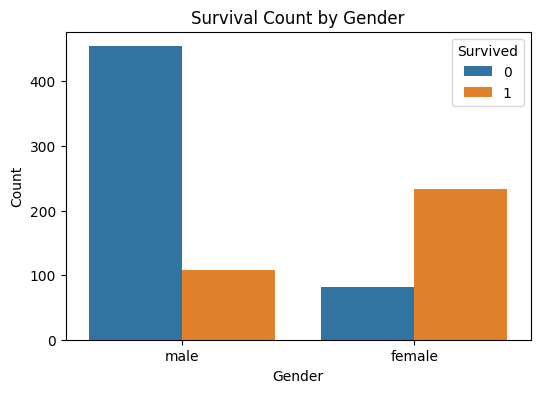

In [85]:
# count plot for displaying survival rate by gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

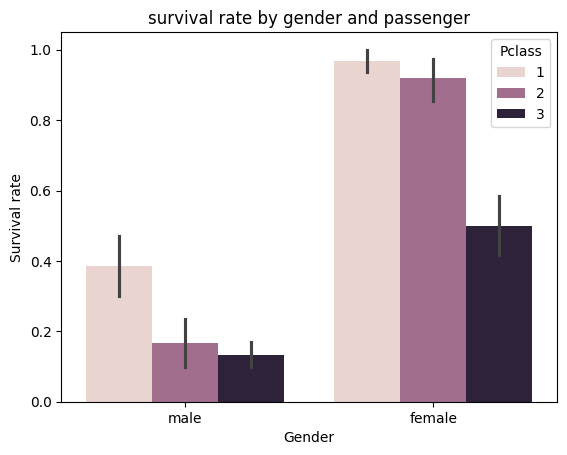

In [86]:
# bar plot for showing survival rate by gender and passenger
sns.barplot(x = 'Sex' , y = 'Survived' , data = df,hue = 'Pclass')
plt.title('survival rate by gender and passenger')
plt.xlabel('Gender')
plt.ylabel('Survival rate')
plt.show()

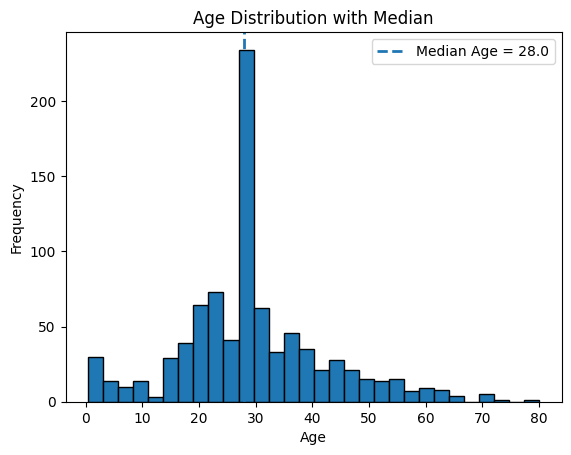

In [54]:
# histogram for the Age column and overlay the median
median_age = df['Age'].median()

plt.hist(df['Age'], bins=30, edgecolor='black')
plt.axvline(median_age, linestyle='--', linewidth=2, label=f'Median Age = {median_age:.1f}')

plt.title('Age Distribution with Median')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

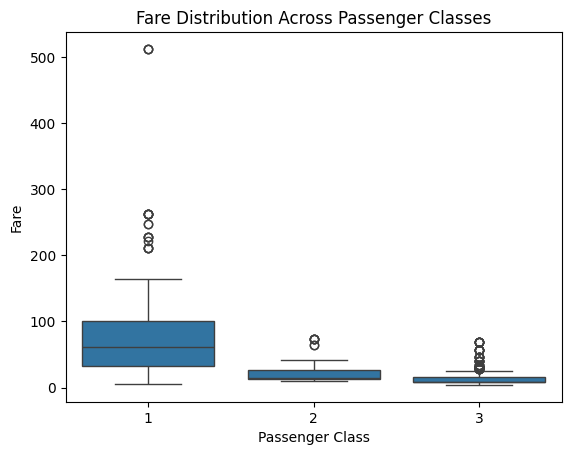

In [87]:
# box plot of Fare across different passenger classes
sns.boxplot(x='Pclass', y='Fare' , data=df)
plt.title('Fare Distribution Across Passenger Classes')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

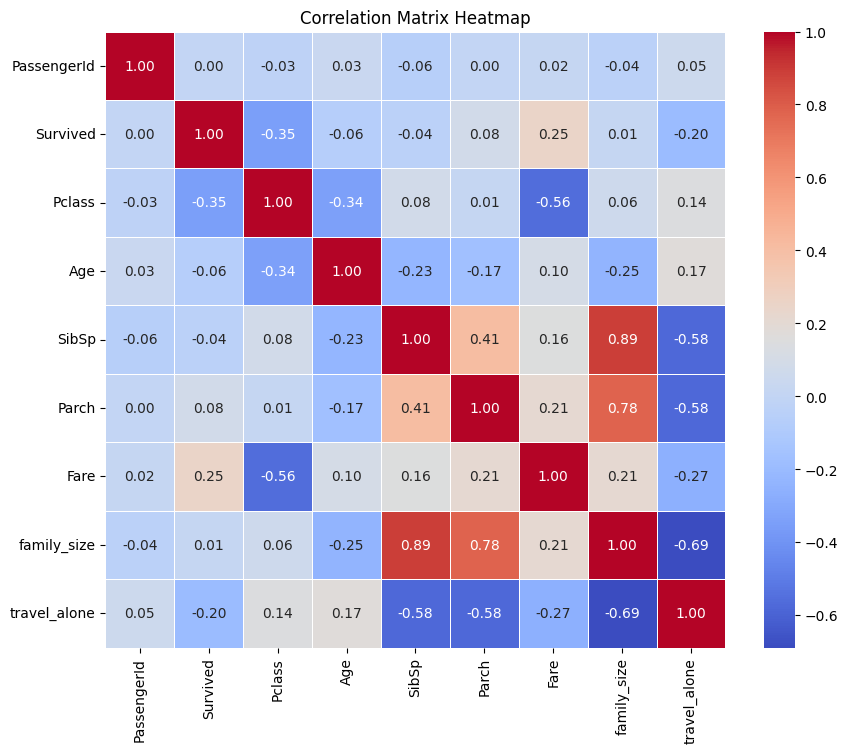

In [88]:
# visualizing the correlation matrix using heatmap
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Task 4: Advanced Data Visualization
1.	Plot geospatial data using the NYC Airbnb Dataset:
○	Visualize the geographic distribution of listings using a scatter plot of latitude and longitude.
○	Create a bar plot of average price per neighborhood.
2.	Identify outliers in the price column using a box plot.


In [89]:
# loading the data set and reading it
data = pd.read_csv('AB_NYC_2019.csv')
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


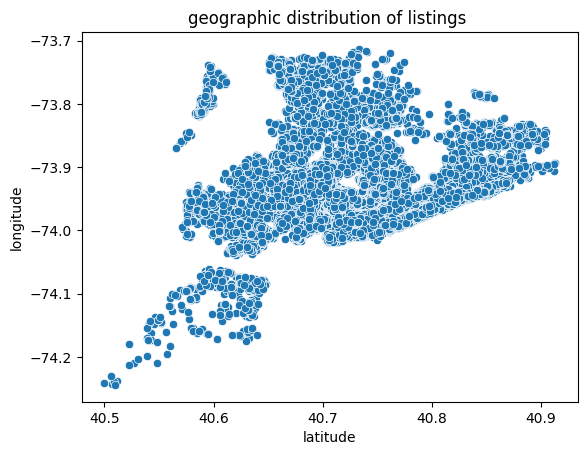

In [90]:
# Visualizing the geographic distribution of listings using a scatter plot of latitude and longitude
sns.scatterplot(x = 'latitude' , y ='longitude' , data = data )
plt.title('geographic distribution of listings ')
plt.xlabel('latitude')
plt.ylabel('longitude')
plt.show()

C:\Users\H.M\AppData\Local\Temp\ipykernel_17828\906501332.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index, y=top10.values, palette='magma')


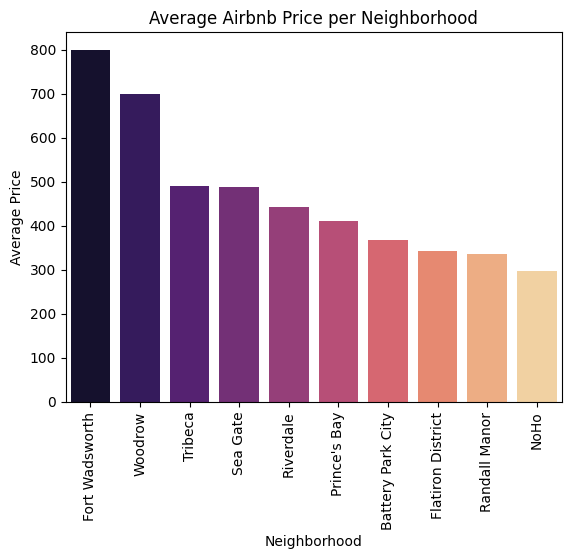

In [91]:
# bar plot of average price per neighborhood 
# displaying top 10 not whole
avg_price = data.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

top10 = avg_price.head(10)
sns.barplot(x=top10.index, y=top10.values, palette='magma')

plt.xticks(rotation=90)
plt.title('Average Airbnb Price per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average Price')
plt.show()

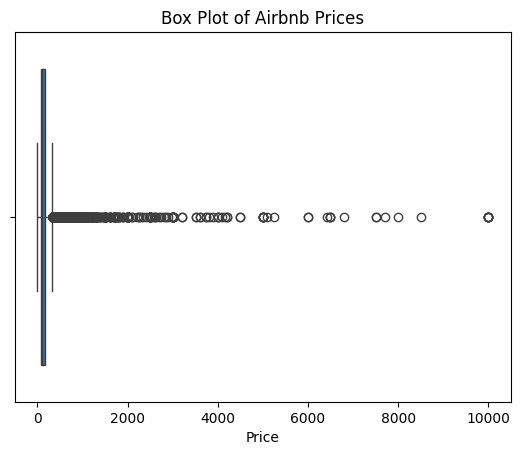

In [92]:
# Identifying outliers in the price column using a box plot
sns.boxplot(x='price' , data = data)

plt.title('Box Plot of Airbnb Prices')
plt.xlabel('Price')
plt.show()

Conclusion

Geospatial plots reveal clear spatial clustering

Bar plot shows price variation by neighborhood

Box plot confirms significant price outliers